## BIS ADVANCED

In [1]:
import sys
import os
import glob
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from funciones_aux import *


### General todos los archivos

In [2]:
# Exploración carpeta raíz datos advanced

ruta_base_advanced = "../data/data_bis_advanced"

for raiz, dirs, files in os.walk(ruta_base_advanced):
    print(f"\nCarpeta: {raiz}")
    print("Subcarpetas:", dirs)
    print("Archivos:", files)


Carpeta: ../data/data_bis_advanced
Subcarpetas: ['M-TA6m-03041035', 'M-TA6m-03041035_2']
Archivos: []

Carpeta: ../data/data_bis_advanced\M-TA6m-03041035
Subcarpetas: ['BIS_TA6m_04032026103520', 'DH03041035', 'DSA_TA6m_04032026103520']
Archivos: []

Carpeta: ../data/data_bis_advanced\M-TA6m-03041035\BIS_TA6m_04032026103520
Subcarpetas: []
Archivos: ['BIS_TA6m_20260304_1-1.pdf']

Carpeta: ../data/data_bis_advanced\M-TA6m-03041035\DH03041035
Subcarpetas: []
Archivos: ['L03041035.ara', 'L03041035.e_a', 'L03041035.f_a', 'L03041035.h_a', 'L03041035.m_a', 'L03041035.o_a', 'L03041035.r2a', 'L03041035.spa', 'L03041035.t_a']

Carpeta: ../data/data_bis_advanced\M-TA6m-03041035\DSA_TA6m_04032026103520
Subcarpetas: []
Archivos: ['DSA_TA6m_20260304_1-1.pdf']

Carpeta: ../data/data_bis_advanced\M-TA6m-03041035_2
Subcarpetas: ['BIS_TA6m_04032026103520', 'DH03041035', 'DSA_TA6m_04032026103520']
Archivos: []

Carpeta: ../data/data_bis_advanced\M-TA6m-03041035_2\BIS_TA6m_04032026103520
Subcarpetas: []


In [ ]:
ruta_base_advanced = "../data/data_bis_advanced"

"""
os.path.join: construye ruta para el SO
**: buscar en todas las subcarpetas del data_bis_advanced
recursive = True: para que mire en carpeta tras carpeta
    Si no está, ** no te recorre la estructura
glob.glob(...): función para buscar archivos por patrón
"""
todos_archivos_advanced = glob.glob(os.path.join(ruta_base_advanced, "**", "L03041035.*"), recursive=True)

"""for archivo in todos_archivos_advanced:
    probar_apertura_texto(archivo, 5)"""

## .f_a

### Directamente sin pasar por el .csv

In [3]:
archivos_fa = localizar_archivos(ruta_base_advanced, "DH*", "*.f_a")
ruta_fa = archivos_fa[0]
print("Archivo seleccionado:", ruta_fa)

vista_preeliminar_texto(ruta_fa, 10)

Se han encontrado 2 archivos *.f_a
Archivo seleccionado: ../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.f_a

--- ../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.f_a ---
S_HDR3             |BIS R2  |4.1                                                                                                                                                                                                                                                                                               |
Time               |Spectra                                                                                                                                                                                                                                                                                                    |
03/04/2026 10:35:21|0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,0000,000

### Carga de archivo
Cargar el archivo .f_a del monitor BIS como un fichero de texto estructurado. 

El separador principal es el carácter |, que delimita una columna temporal (Time) y una columna con la información espectral (Spectra).

La columna Spectra contiene 60 valores por instante temporal, separados por comas, que corresponden a las bandas de frecuencia de la matriz DSA. Estas bandas abarcan desde 0.5 Hz hasta 30 Hz con una resolución de 0.5 Hz.

Una vez expandida la columna espectral, se obtiene una matriz de dimensiones tiempo × frecuencia, que puede representarse como imagen en forma de mapa de calor. En dicha representación, el eje horizontal corresponde al tiempo, el eje vertical a la frecuencia y el color a la intensidad espectral.

La resolución temporal real se verifica calculando la diferencia entre marcas temporales consecutivas. En los datos analizados, esta separación es de 1 segundo por fila.

Los valores espectrales aparecen almacenados como enteros escalados. Tras aplicar un factor de corrección de 1/100, el mapa de color se interpreta como potencia espectral en dB, pendiente de confirmación definitiva con la documentación técnica del dispositivo.

In [4]:
def cargar_fa_directo(ruta_fa, escalar_db=True):
    """
    Carga un archivo .f_a directamente en un DataFrame.
    Devuelve:
    - tiempo: serie temporal
    - dsa: matriz espectral (filas=tiempo, columnas=frecuencia)
    """


    """
    ruta_fa: ruta del archivo
    sep="|": le dice a pandas que el separador principal es |
    header=None: le dice que no use ninguna fila como nombres de columnas
    skiprows=2: se salta las dos primeras líneas del archivo que so cabecera
    engine="python": usa el motor de Python para leerlo, que suele ser más flexible con archivos raros
    """
    df = pd.read_csv(
        ruta_fa,
        sep="|",
        header=None,
        skiprows=2,
        engine="python"
    )


    """
    print(df.shape)
    print(df.head())
    Esto nos muestra que al principio hay 3 columnas
    """


    # limpiar columnas vacías generadas por el | final
    df = df.dropna(axis=1, how="all") # axis=1 es columnas. Elimina solo si toda la columna está vacía
    
    # Para quedarme solo con las dos primeras columnas del DataFrame
    """ 
    iloc sirve para seleccionar por posición, por número de fila y número de columna
     - : en la parte de filas selecciona todas las filas
     - : :2 en la parte de columnas selecciona desde la columna 0 a la 1
    Realmente esto es para asegurarse de que solo se conservarán las dos columnas
    """
    df = df.iloc[:, :2]

    # df.columns es la lista de nombres de columnas del DataFrame. Aquí renombra las columnas.
    df.columns = ["Time", "Spectra"]


    # Convertir tiempo
    """ 
    Selecciona la columna de Time que está en formato texto
    Quita espacios sobrantes al principio y al final de cada valor de texto
    Transforma texto en fecha-hora de pandas y pone el formato que BIS suele usar el americano

    errors="coerce": si algún valor no se puede convertir bien se convierte en NaT
    """
    df["Time"] = pd.to_datetime(
        df["Time"].str.strip(),
        format="%m/%d/%Y %H:%M:%S",
        errors="coerce"
    )


    # Separar los 60 valores espectrales
    """ 
    Cada fila de Spectra es un único texto largo con 60 valores separados por comas.
    Se quitan los espacios sobrantes al principio y fin de texto
    Se divide el texto usando la coma de separador

    expand=True: convierte cada elemento del split (números que estaban en una lista) en una columna distinta

    Este DataFrame ya es esencialmente la matriz DSA:
     - filas = instantes temporales
     - columnas = bandas de frecuencia
     - valores = intensidad espectral

    Falta convertir valores a número y colocar nombres de frecuencia
    """
    dsa = df["Spectra"].str.strip().str.split(",", expand=True)
    
    # convertir esas columnas de texto en números reales que son decibelios
    dsa = dsa.apply(pd.to_numeric, errors="coerce") 



    # Escalado: si está activada la corrección de escala, divide toda la matriz espectral entre 100 para obtener los valores reales
    if escalar_db:
        dsa = dsa / 100



    # crea el eje de frecuencias: 0.5 a 30 Hz. 
    # np.arange genera números espaciados regularmente. 
    # 30.0 + 0.5 porque el límite final no siempre se incluye directamente
    frecuencias = np.arange(0.5, 30.0 + 0.5, 0.5)

    # Cambia los nombres de las columnas de dsa.
    dsa.columns = frecuencias


    """ 
    Devuelve una serie temporal de pandas y la matriz dsa

    No se devuelve un único df final:
     - tiempo: 
        filas: una por instante temporal
        contenido: timestamp
        tipo: datetime64[ns]

     - dsa:
        filas: instantes temporales
        columnas: frecuencias
        valores: intensidad espectral
    """
    return df["Time"], dsa




In [5]:
tiempo, dsa = cargar_fa_directo(ruta_fa, escalar_db=True)

print("Dimensiones de la matriz:", dsa.shape)
print("Frecuencias:", dsa.columns.min(), "a", dsa.columns.max(), "Hz")

# salto entre una banda de frecuencia y la siguiente. La diferencia entre columnas consecutivas es 0.5
print("Resolución en frecuencia:", dsa.columns[1] - dsa.columns[0], "Hz")

Dimensiones de la matriz: (2119, 60)
Frecuencias: 0.5 a 30.0 Hz
Resolución en frecuencia: 0.5 Hz


In [6]:
"""
Si se quiere recomponer el df final en el que hay 61 columnas:
 - 1º: Time. Se fuerza a que cuando se convierta en columna se llame Time
 - siguientes: frecuencias de 0.5 Hz a 30 Hz

"""
df_final = pd.concat([tiempo.rename("Time"), dsa], axis=1)
print(df_final)


                    Time    0.5    1.0    1.5     2.0    2.5    3.0    3.5  \
0    2026-03-04 10:35:21   0.00   0.00   0.00    0.00   0.00   0.00   0.00   
1    2026-03-04 10:35:22   0.00   0.00   0.00    0.00   0.00   0.00   0.00   
2    2026-03-04 10:35:23   0.00   0.00   0.00    0.00   0.00   0.00   0.00   
3    2026-03-04 10:35:24   0.00   0.00   0.00    0.00   0.00   0.00   0.00   
4    2026-03-04 10:35:25  93.56  98.12  97.43  100.48  99.82  96.09  93.46   
...                  ...    ...    ...    ...     ...    ...    ...    ...   
2114 2026-03-04 11:10:35  90.55  96.27  94.19   92.74  95.19  93.69  90.17   
2115 2026-03-04 11:10:36  90.40  96.17  94.13   92.50  94.99  93.46  90.04   
2116 2026-03-04 11:10:37  90.25  96.09  94.11   92.26  94.71  93.20  89.88   
2117 2026-03-04 11:10:38  90.11  96.01  94.11   92.03  94.38  92.90  89.71   
2118 2026-03-04 11:10:39  89.97  95.94  94.13   91.80  94.00  92.58  89.53   

        4.0     4.5  ...   25.5   26.0   26.5   27.0   27.5   2

### vista tipo PDF BIS

Esta vista intenta parecerse al PDF:

 - tiempo en vertical
 - frecuencia en horizontal
 - mismo mapa de color.
 - líneas discontinuas de bandas EEG


In [7]:
matriz = dsa.values
print(matriz)

[[ 0.    0.    0.   ...  0.    0.    0.  ]
 [ 0.    0.    0.   ...  0.    0.    0.  ]
 [ 0.    0.    0.   ...  0.    0.    0.  ]
 ...
 [90.25 96.09 94.11 ... 78.68 78.69 78.49]
 [90.11 96.01 94.11 ... 78.38 78.48 78.09]
 [89.97 95.94 94.13 ... 78.11 78.27 77.73]]


In [8]:
print("Valor mínimo:", np.nanmin(dsa.values))
print("Valor máximo:", np.nanmax(dsa.values))

Valor mínimo: 0.0
Valor máximo: 103.02


In [9]:
print("Valor mínimo:", dsa.min().min())
print("Valor máximo:", dsa.max().max())

Valor mínimo: 0.0
Valor máximo: 103.02


In [10]:
print(tiempo)

0      2026-03-04 10:35:21
1      2026-03-04 10:35:22
2      2026-03-04 10:35:23
3      2026-03-04 10:35:24
4      2026-03-04 10:35:25
               ...        
2114   2026-03-04 11:10:35
2115   2026-03-04 11:10:36
2116   2026-03-04 11:10:37
2117   2026-03-04 11:10:38
2118   2026-03-04 11:10:39
Name: Time, Length: 2119, dtype: datetime64[ns]


In [11]:
y0 = mdates.date2num(tiempo.iloc[0]) # prim instante temporal
y1 = mdates.date2num(tiempo.iloc[-1]) # último

print(y0)
print(y1)

20516.441215277777
20516.465729166666


In [12]:
def plot_dsa_estilo_pdf(tiempo, dsa, vmin=None, vmax=None, cmap="jet"):
    """
    DSA con estilo parecido al PDF del BIS:

    """

    
    # conversión del dF DSA en una matriz numérica
    matriz = dsa.values


    """ 
    Creación de la figura y el eje donde se dibujará la DSA
    Esta es la alta y estrecha porque es la que se parece a la del PDF
    """
    fig, ax = plt.subplots(figsize=(4.8, 10))


    """ 
    Antes de dibujar la DSA como imagen hay que saber los valores del eje X y del Y
     - X: frecuencias reales de 0.5 a 30 Hz
     - Y: tiempo. Línea del tiempo desde que comienza a grabar el BIS hasta que acaba
    """

    # hay que saber donde empiezan y terminan los ejes. imshow pide los 4 bordes

    y0 = mdates.date2num(tiempo.iloc[0]) # prim instante temporal
    y1 = mdates.date2num(tiempo.iloc[-1]) # último
    x0 = dsa.columns.min() # frecuencia mínima
    x1 = dsa.columns.max() # máxima


    """ 
    imshow dibuja la matriz como un bloque de colores donde cada número es un color
    cada celda de matriz tiene un valor numérico

    aspect="auto": se quiere DSA alta y estrecha, así que dejamos que la imagen se adapte a la forma de la figura
    origin="upper": dónde colocar la primera fila de la matriz. La fila 0 arriba

    extent=[x0, x1, y1, y0]: rectángulo de imagen ocupa estas coordenadas reales [left, right, bottom, top]
    cmap=cmap: definir la paleta de colores
        
    vmin: todo valor igual o inferior a vmin se pinta con el color más bajo del colormap
    vmax: todo valor igual o superior a vmax se pinta con el color más alto del colormap
    """
    im = ax.imshow(
        matriz,
        aspect="auto",
        origin="upper",
        extent=[x0, x1, y1, y0],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    # Invertir eje X: 30 Hz a la izquierda
    ax.invert_xaxis()

    # Formato del tiempo
    ax.yaxis_date()
    ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

    # Etiquetas de ejes
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("DSA", loc="left", fontsize=10, pad=6)

    # Marcas principales de frecuencia
    marcas_freq = [30, 13, 8, 4]
    ax.set_xticks(marcas_freq)
    ax.set_xticklabels(["30Hz", "13Hz", "8Hz", "4Hz"], fontsize=8)

    # Líneas discontinuas grises para separar bandas
    for f in [13, 8, 4]:
        ax.axvline(f, color="gray", linestyle="--", linewidth=1, alpha=0.7)

    # Nombres de las bandas arriba
    # Como el eje está invertido, los centros se calculan igual y matplotlib los coloca bien
    bandas = {
        "Beta":  (13 + 30) / 2,
        "Alpha": (8 + 13) / 2,
        "Theta": (4 + 8) / 2,
        "Delta": (0.5 + 4) / 2,
    }

    for nombre, xpos in bandas.items():
        ax.text(
            xpos,
            1.01,
            nombre,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=45
        )

    # Barra de color
    cbar = plt.colorbar(im, ax=ax, pad=0.03)
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels(["Min", "Max"])
    cbar.ax.tick_params(length=0)
    cbar.set_label("Intensidad espectral (dB)", rotation=90, labelpad=12)


    plt.tight_layout()
    plt.show()

In [13]:
# Escala de color común para ambas figuras
vmin = np.nanpercentile(dsa.values, 5)
vmax = np.nanpercentile(dsa.values, 95)


### vista horizontal tipo análisis

In [14]:
def plot_dsa_horizontal(tiempo, dsa, vmin=None, vmax=None, cmap="jet"):
    matriz = dsa.T.values  # filas = frecuencia, columnas = tiempo

    fig = plt.figure(figsize=(14, 5))
    gs = fig.add_gridspec(1, 3, width_ratios=[20, 1.5, 0.5], wspace=0.08)

    ax = fig.add_subplot(gs[0, 0])       # DSA
    ax_band = fig.add_subplot(gs[0, 1])  # nombres de bandas
    cax = fig.add_subplot(gs[0, 2])      # colorbar

    x0 = mdates.date2num(tiempo.iloc[0])
    x1 = mdates.date2num(tiempo.iloc[-1])
    y0 = dsa.columns.min()
    y1 = dsa.columns.max()

    im = ax.imshow(
        matriz,
        aspect="auto",
        origin="lower",
        extent=[x0, x1, y0, y1],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
    plt.setp(ax.get_xticklabels(), rotation=45)

    ax.set_xlabel("Tiempo")
    ax.set_ylabel("Frecuencia (Hz)")
    ax.set_title("DSA horizontal")

    # Líneas discontinuas de bandas
    for f in [4, 8, 13]:
        ax.axhline(f, color="gray", linestyle="--", linewidth=1, alpha=0.7)

    # Eje lateral para nombres de bandas
    ax_band.set_ylim(y0, y1)
    ax_band.set_xlim(0, 1)
    ax_band.axis("off")

    bandas = {
        "Delta": (0.5 + 4) / 2,
        "Theta": (4 + 8) / 2,
        "Alpha": (8 + 13) / 2,
        "Beta":  (13 + 30) / 2,
    }

    for nombre, ypos in bandas.items():
        ax_band.text(0.05, ypos, nombre, va="center", ha="left", fontsize=9)

    # Barra de color
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels(["Min", "Max"])
    cbar.ax.tick_params(length=0)
    cbar.set_label("Intensidad espectral (dB)", rotation=90, labelpad=12)

    plt.show()

In [15]:

delta_t = tiempo.diff().dt.total_seconds().dropna()

print("\nResolución temporal:")
print(delta_t.describe())
print(delta_t.value_counts().sort_index())


Resolución temporal:
count    2118.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: Time, dtype: float64
Time
1.0    2118
Name: count, dtype: int64


#### Unidades del mapa de color

Los valores espectrales están almacenados escalados por un factor 100 y, tras corregirlo, el mapa de color representa potencia espectral en dB.



#### Resolución temporal real

La resolución temporal real del archivo .f_a es de 1 segundo por fila.

In [16]:
"""
buscar_lineas_por_intervalo(
    ruta_fa,
    "03/04/2026 10:45:00",
    "03/04/2026 10:48:00"
)
"""

'\nbuscar_lineas_por_intervalo(\n    ruta_fa,\n    "03/04/2026 10:45:00",\n    "03/04/2026 10:48:00"\n)\n'

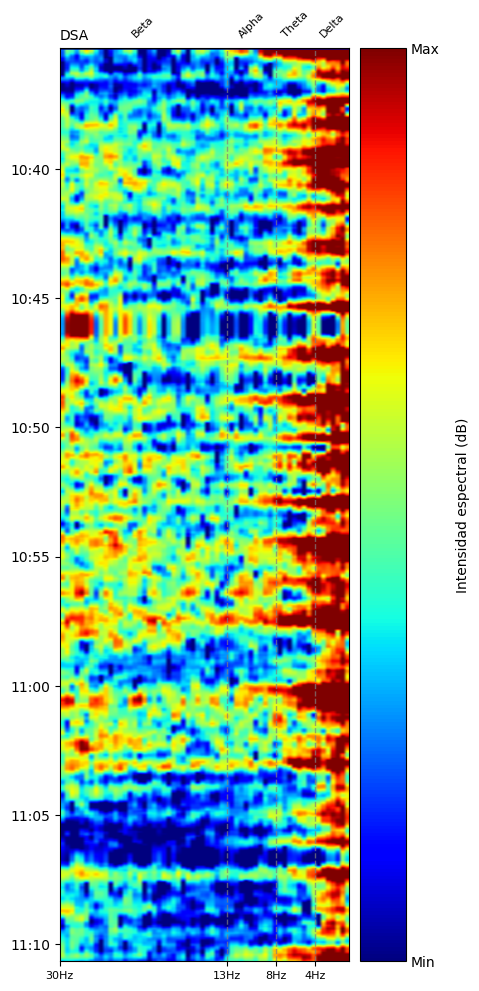

In [17]:
plot_dsa_estilo_pdf(tiempo, dsa, vmin=vmin, vmax=vmax, cmap="jet")

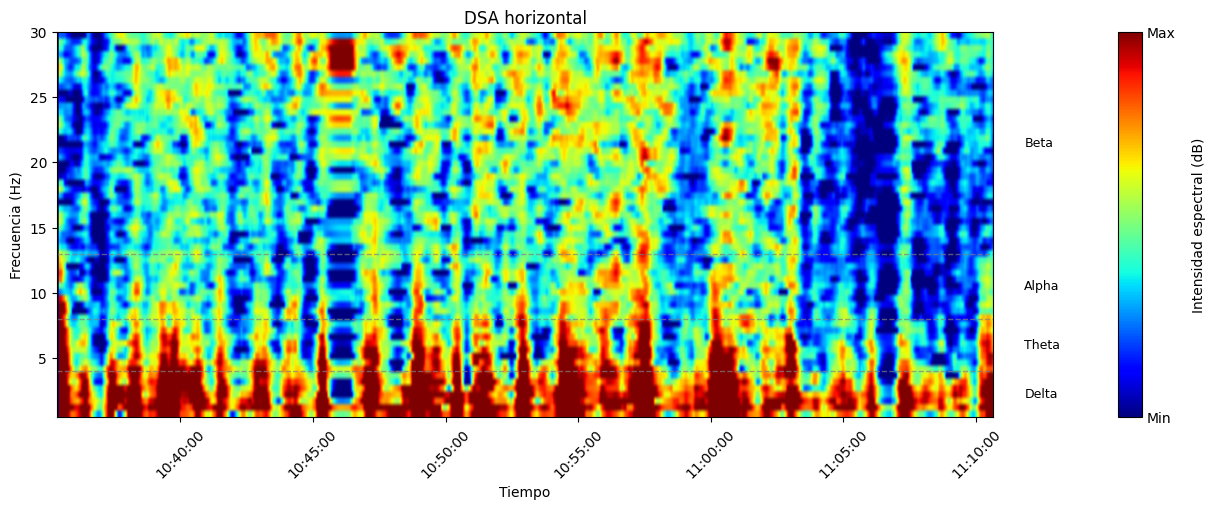

In [18]:
plot_dsa_horizontal(tiempo, dsa, vmin=vmin, vmax=vmax, cmap="jet")

La representación obtenida a partir del archivo .f_a reproduce la estructura de la matriz DSA, pero no coincide exactamente con la imagen generada por el monitor BIS. 

Esto sugiere que el sistema aplica un procesado visual adicional sobre la matriz base, incluyendo suavizado, reescalado del mapa de color, interpolación y superposición de curvas derivadas.

Diferencias con el .pdf de la DSA:

 - El BIS no dibuja la matriz cruda: el heatmap usa directamente los valores de cada celda del .f_a
    suavizado temporal
    suavizado en frecuencia
    interpolación visual
    recorte de valores extremos
    reescalado del contraste

 - La escala de color no es la misma
 - El .f_a será la base numérica, pero el PDF es una versión renderizada clínicamente: versión procesada, combinación del archivo con otros cálculos
 - No tengo las superposiciones de las líneas morada y blanca
 - No coincidencia exacta del rango temporal: hay bloques separados en el PDF porque hay zonas no válidas y eso se enseña pero en mi figura el espectro es continuo y no hay recortes visuales

### Para recorrer todos los .f_a

In [19]:
for ruta_fa in archivos_fa:
    print("\nProcesando:", ruta_fa)
    tiempo, dsa = cargar_fa_directo(ruta_fa)
    print("Shape:", dsa.shape)


Procesando: ../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.f_a
Shape: (2119, 60)

Procesando: ../data/data_bis_advanced\M-TA6m-03041035_2\DH03041035\L03041035.f_a
Shape: (2119, 60)


### archivo r2a

In [21]:
archivos_r2a = glob.glob(os.path.join(ruta_base_advanced, "**", "*.r2a"), recursive=True)

print(f"Encontrados {len(archivos_r2a)} archivos .r2a")
for archivo in archivos_r2a:
    print(archivo)

Encontrados 2 archivos .r2a
../data/data_bis_advanced\M-TA6m-03041035\DH03041035\L03041035.r2a
../data/data_bis_advanced\M-TA6m-03041035_2\DH03041035\L03041035.r2a


In [22]:
def ver_binario(ruta, n_bytes=64):
    with open(ruta, "rb") as f:
        contenido = f.read(n_bytes)
    print(contenido)

ver_binario(archivos_r2a[0], 100)

b"B\xf4\xce\xf3\xf2\xf3\xcb\xf2'\xf5$\xf4i\xf4\xd6\xf4\x1e\xf4\n\xf4F\xf4C\xf4\xd4\xf4\xd8\xf3\xdb\xf5n\xf3\xc7\xf7\x15\xf3\x8d\xf91\xf3\xeb\xfb\xdd\xf2\xab\xfc$\xf38\xfd\xcf\xf4^\xfe\x92\xf6\xc4\xfe\xa5\xf3\x9f\xfd\xca\xf1y\xfd\xce\xf3\xed\xfbX\xf5\t\xfc\x1c\xf3\xd6\xfa\x07\xf4~\xf9\xa8\xf6\xfc\xf8\xfe\xf5&\xf9E\xf4\x88\xf8\\\xf55\xf8\x96\xf5"


In [35]:
# Ruta de tu archivo de ondas crudas (asegúrate de que la ruta sea correcta)
archivo_r2a = r"../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.r2a"

print("=== PRIMEROS BYTES DEL ARCHIVO CRUDO (.r2a) ===")
print("Offset    Hexadecimal                                      Texto ASCII")
print("-" * 75)

with open(archivo_r2a, "rb") as archivo:
    offset = 0
    # Leemos solo 10 bloques de 16 bytes (160 bytes en total)
    for _ in range(10):
        chunk = archivo.read(16)
        if not chunk: # Si el archivo se acaba antes, paramos
            break
        
        # 1. Convertir a hexadecimal
        hex_data = " ".join(f"{byte:02x}" for byte in chunk)
        
        # 2. Convertir a texto ASCII (ocultando caracteres no legibles)
        ascii_data = "".join(chr(byte) if 32 <= byte <= 126 else "." for byte in chunk)
        
        # Imprimir la fila estructurada
        print(f"{offset:08x}  {hex_data:<47}  |{ascii_data}|")
        offset += 16

=== PRIMEROS BYTES DEL ARCHIVO CRUDO (.r2a) ===
Offset    Hexadecimal                                      Texto ASCII
---------------------------------------------------------------------------
00000000  42 f4 ce f3 f2 f3 cb f2 27 f5 24 f4 69 f4 d6 f4  |B.......'.$.i...|
00000010  1e f4 0a f4 46 f4 43 f4 d4 f4 d8 f3 db f5 6e f3  |....F.C.......n.|
00000020  c7 f7 15 f3 8d f9 31 f3 eb fb dd f2 ab fc 24 f3  |......1.......$.|
00000030  38 fd cf f4 5e fe 92 f6 c4 fe a5 f3 9f fd ca f1  |8...^...........|
00000040  79 fd ce f3 ed fb 58 f5 09 fc 1c f3 d6 fa 07 f4  |y.....X.........|
00000050  7e f9 a8 f6 fc f8 fe f5 26 f9 45 f4 88 f8 5c f5  |~.......&.E...\.|
00000060  35 f8 96 f5 25 f7 f3 f4 15 f7 ef f4 12 f8 a0 f5  |5...%...........|
00000070  25 f7 79 f5 84 f7 fd f5 2b f8 e4 f5 a7 f6 2d f6  |%.y.....+.....-.|
00000080  fc f6 0f f6 01 f8 48 f6 61 f6 b9 f6 e3 f5 30 f7  |......H.a.....0.|
00000090  5f f7 3c f6 de f6 82 f6 14 f6 4e f6 d6 f5 d3 f5  |_.<.......N.....|


In [36]:
import struct

# Rutas de archivos
archivo_entrada = r"../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.r2a"
archivo_salida = "voltajes_cerebrales.csv"

print("Iniciando conversión de ondas crudas...")

with open(archivo_entrada, "rb") as f_in, open(archivo_salida, "w") as f_out:
    # Escribimos una cabecera para el CSV
    f_out.write("Muestra,Voltaje_Raw\n")
    
    contador = 0
    # Leemos de 2 en 2 bytes (una muestra de 16 bits)
    while True:
        bytes_muestra = f_in.read(2)
        if not bytes_muestra or len(bytes_muestra) < 2:
            break
        
        # Traducimos de Hexadecimal a Entero con signo
        # '<h' es el molde para 16 bits signed little-endian
        voltaje = struct.unpack('<h', bytes_muestra)[0]
        
        # Escribimos en el archivo de texto
        f_out.write(f"{contador},{voltaje}\n")
        
        contador += 1
        
        # Para no trabajar a ciegas, imprimimos un aviso cada 100.000 muestras
        if contador % 100000 == 0:
            print(f"Procesadas {contador} muestras...")

print(f"¡Hecho! Se han traducido {contador} muestras.")
print(f"Puedes abrir el archivo '{archivo_salida}' para ver los datos.")

Iniciando conversión de ondas crudas...
Procesadas 100000 muestras...
Procesadas 200000 muestras...
Procesadas 300000 muestras...
Procesadas 400000 muestras...
Procesadas 500000 muestras...
¡Hecho! Se han traducido 542624 muestras.
Puedes abrir el archivo 'voltajes_cerebrales.csv' para ver los datos.


In [ ]:
tiempo_en_segundos = contador / 128.0 / 2

In [41]:
print(contador)
print(tiempo_en_segundos)

542624
2119.625


### archivo .h_a

In [25]:
archivo_bin = "../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.h_a" 

with open(archivo_bin, "rb") as archivo:
    contenido = archivo.read()

# 2. Vamos a ver los primeros 32 bytes en hexadecimal, separados por espacios
primeros_bytes = contenido[:32]
print("Datos en bruto (Hexadecimal):")
print(contenido.hex(' '))

Datos en bruto (Hexadecimal):
ff 0b 1d 34 80 03 04 00 01 00 00 00 ff ff ff ff 4c 00 4c 30 33 30 34 31 30 33 35 2e 68 5f 61 00 40 8f 10 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 b0 17 a8 69 00 00 00 00 b0 17 a8 69 00 00 00 00 b5 17 a8 69 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 0d 02 00 00 00 00 00 02 00 80 00 00 00 42 49 53 2d 52 32 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 42 49 53 2d 52 32 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 42 49 53 2d 52 32 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 42 49 53 2d 52 32 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 0

In [26]:
import struct

# Tu ruta del archivo
archivo_bin = r"../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.h_a"

with open(archivo_bin, "rb") as archivo:
    contenido = archivo.read()

print("=== MAPA DEL ARCHIVO DE CABECERA (.h_a) ===")
print("-" * 50)

# 1. Leer el nombre del archivo (Bytes 18 al 31)
inicio, fin = 18, 32
texto_crudo = struct.unpack('14s', contenido[inicio:fin])[0]
nombre_archivo = texto_crudo.decode('ascii').replace('\x00', '')
print(f"Nombre del archivo:      {nombre_archivo}")

# Extraer la hora real desde el nombre del archivo (L + Mes + Día + Hora + Min)
# Sabiendo que el formato es L03041035
hora_inicio = nombre_archivo[5:7]
minuto_inicio = nombre_archivo[7:9]
print(f"Hora de inicio deducida: {hora_inicio}:{minuto_inicio}:xx")

# 2. Encontrar el nombre del Algoritmo
texto_buscar = b"BIS-R2"
posicion_algo = contenido.find(texto_buscar)

if posicion_algo != -1:
    inicio, fin = posicion_algo, posicion_algo + 6
    version_algo = struct.unpack('6s', contenido[inicio:fin])[0].decode('ascii')
    print(f"Motor del algoritmo:     {version_algo}")

# 3. Encontrar los parámetros de Filtro Float (0.05 Hz)
secuencia_float = bytes.fromhex('cdcc4c3d')
posicion_float = contenido.find(secuencia_float)

if posicion_float != -1:
    inicio, fin = posicion_float, posicion_float + 4
    valor_filtro = struct.unpack('<f', contenido[inicio:fin])[0]
    print(f"Configuración de Filtro: {valor_filtro:.2f} Hz")

=== MAPA DEL ARCHIVO DE CABECERA (.h_a) ===
--------------------------------------------------
Nombre del archivo:      L03041035.h_a
Hora de inicio deducida: 10:35:xx
Motor del algoritmo:     BIS-R2
Configuración de Filtro: 0.05 Hz


In [27]:
# Ruta de tu archivo
archivo_bin = r"../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.h_a"

print("Offset    Hexadecimal                                      Texto ASCII")
print("-" * 75)

with open(archivo_bin, "rb") as archivo:
    offset = 0
    # Leer el archivo en bloques de 16 bytes
    while True:
        chunk = archivo.read(16)
        if not chunk:
            break
        
        # 1. Convertir a hexadecimal (ej: 'ff 0b 1d...')
        hex_data = " ".join(f"{byte:02x}" for byte in chunk)
        
        # 2. Convertir a texto (solo caracteres legibles, el resto se vuelve '.')
        ascii_data = "".join(chr(byte) if 32 <= byte <= 126 else "." for byte in chunk)
        
        # Imprimir fila con formato alineado
        # :08x formatea el offset a 8 ceros hexadecimales
        # :<47 alinea la columna hex a la izquierda
        print(f"{offset:08x}  {hex_data:<47}  |{ascii_data}|")
        
        offset += 16

Offset    Hexadecimal                                      Texto ASCII
---------------------------------------------------------------------------
00000000  ff 0b 1d 34 80 03 04 00 01 00 00 00 ff ff ff ff  |...4............|
00000010  4c 00 4c 30 33 30 34 31 30 33 35 2e 68 5f 61 00  |L.L03041035.h_a.|
00000020  40 8f 10 00 00 00 00 00 00 00 00 00 00 00 00 00  |@...............|
00000030  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00  |................|
00000040  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00  |................|
00000050  00 00 00 00 b0 17 a8 69 00 00 00 00 b0 17 a8 69  |.......i.......i|
00000060  00 00 00 00 b5 17 a8 69 00 00 00 00 00 00 00 00  |.......i........|
00000070  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00  |................|
00000080  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00  |................|
00000090  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00  |................|
000000a0  00 00 00 00 00 00 00 00 00 00 00 00 00 00 00 00  |.............

### Archivo .spa

In [28]:
import pandas as pd

def procesar_spa(ruta_spa):
    # Leer los datos
    df = pd.read_csv(
        ruta_spa,
        sep="|",
        header=None,
        skiprows=2,
        engine="python"
    )

    # Eliminar columnas completamente vacías
    df = df.dropna(axis=1, how="all")

    # Leer la segunda línea como nombres de columnas
    with open(ruta_spa, "r", errors="ignore") as f:
        _ = f.readline()                      # primera cabecera
        cabecera = f.readline().strip("\n")  # segunda cabecera

    nombres = [x.strip() for x in cabecera.split("|")]
    nombres = nombres[:df.shape[1]]

    # Hacer nombres únicos
    contador = {}
    nombres_unicos = []

    for col in nombres:
        if col == "":
            col = "col_vacia"

        if col in contador:
            contador[col] += 1
            nombres_unicos.append(f"{col}_{contador[col]}")
        else:
            contador[col] = 1
            nombres_unicos.append(col)

    df.columns = nombres_unicos

    # Convertir la fecha
    if "Time" in df.columns:
        df["Time"] = pd.to_datetime(
            df["Time"],
            format="%m/%d/%Y %H:%M:%S",
            errors="coerce"
        )

    return df

In [29]:
ruta_spa = "../data/data_bis_advanced/M-TA6m-03041035/DH03041035/L03041035.spa"
df_spa = procesar_spa(ruta_spa)

display(df_spa.head())
print(df_spa.shape)
print(df_spa.columns.tolist())

,Time,SpSmooth,BiSmooth,LoFilter,NotFiltr,HiFilter,PIC_ID,SR12,SEF08,MEDFRQ08,...,SQI10_3,IMPEDNCE_3,ARTF2_3,BURST_3,ST_3,C1POSIMP,C1NEGIMP,GNDIMP,C2POSIMP,C2NEGIMP
0,2026-03-04 10:35:21,3,0,3,3,2,27,-3276.8,-327.7,-327.7,...,0.0,1.8,0200810c,-3276,0.0,,,,,
1,2026-03-04 10:35:22,3,0,3,3,2,27,-3276.8,-327.7,-327.7,...,0.0,3.6,02000000,-3276,0.0,,,,,
2,2026-03-04 10:35:23,3,0,3,3,2,27,-3276.8,-327.7,-327.7,...,0.0,2.6,02000000,-3276,0.0,,,,,
3,2026-03-04 10:35:24,3,0,3,3,2,27,-3276.8,-327.7,-327.7,...,0.0,3.5,00000088,-3276,0.0,,,,,
4,2026-03-04 10:35:25,3,0,3,3,2,27,-3276.8,-327.7,-327.7,...,0.8,3.2,00000180,-3276,0.0,,,,,


(2119, 54)
['Time', 'SpSmooth', 'BiSmooth', 'LoFilter', 'NotFiltr', 'HiFilter', 'PIC_ID', 'SR12', 'SEF08', 'MEDFRQ08', 'BISBIT00', 'DB13U01', 'DB11U04', 'B34U05', 'TOTPOW08', 'EMGLOW01', 'SQI10', 'IMPEDNCE', 'ARTF2', 'BURST', 'ST', 'SR12_2', 'SEF08_2', 'MEDFRQ08_2', 'BISBIT00_2', 'DB13U01_2', 'DB11U04_2', 'B34U05_2', 'TOTPOW08_2', 'EMGLOW01_2', 'SQI10_2', 'IMPEDNCE_2', 'ARTF2_2', 'BURST_2', 'ST_2', 'SR12_3', 'SEF08_3', 'MEDFRQ08_3', 'BISBIT00_3', 'DB13U01_3', 'DB11U04_3', 'B34U05_3', 'TOTPOW08_3', 'EMGLOW01_3', 'SQI10_3', 'IMPEDNCE_3', 'ARTF2_3', 'BURST_3', 'ST_3', 'C1POSIMP', 'C1NEGIMP', 'GNDIMP', 'C2POSIMP', 'C2NEGIMP']


In [30]:
display(df_spa.iloc[200: 240: 2, :20])

,Time,SpSmooth,BiSmooth,LoFilter,NotFiltr,HiFilter,PIC_ID,SR12,SEF08,MEDFRQ08,BISBIT00,DB13U01,DB11U04,B34U05,TOTPOW08,EMGLOW01,SQI10,IMPEDNCE,ARTF2,BURST
200,2026-03-04 10:38:41,3,0,3,3,2,27,0.0,22.5,7.3,20bc,97.1,-3276.0,-3276.0,73.1,62.0,58.3,6.4,00000000,-3276
202,2026-03-04 10:38:43,3,0,3,3,2,27,0.0,22.0,7.1,20bc,97.3,-3276.0,-3276.0,73.2,61.4,59.6,4.0,00000080,-3276
204,2026-03-04 10:38:45,3,0,3,3,2,27,0.0,22.1,7.0,20bc,97.3,-3276.0,-3276.0,73.1,60.7,60.9,8.2,00000280,-3276
206,2026-03-04 10:38:47,3,0,3,3,2,27,0.0,22.6,7.1,20bc,97.3,-3276.0,-3276.0,72.8,60.1,62.2,8.9,00000080,-3276
208,2026-03-04 10:38:49,3,0,3,3,2,27,0.0,23.7,7.3,20bc,97.3,-3276.0,-3276.0,72.1,61.5,64.7,4.8,00000000,-3276
210,2026-03-04 10:38:51,3,0,3,3,2,27,0.0,25.0,7.9,20bc,97.3,-3276.0,-3276.0,70.6,63.0,67.3,3.6,00000180,-3276
212,2026-03-04 10:38:53,3,0,3,3,2,27,0.0,26.5,8.7,20bc,97.6,-3276.0,-3276.0,67.9,64.6,69.9,8.5,00000080,-3276
214,2026-03-04 10:38:55,3,0,3,3,2,27,0.0,26.9,9.4,20bc,97.6,-3276.0,-3276.0,67.1,63.6,71.2,10.4,00000080,-3276
216,2026-03-04 10:38:57,3,0,3,3,2,27,0.0,26.9,9.5,20bc,97.6,-3276.0,-3276.0,67.1,63.3,71.2,7.1,00000080,-3276
218,2026-03-04 10:38:59,3,0,3,3,2,27,0.0,26.9,9.5,20bc,97.6,-3276.0,-3276.0,67.1,63.0,68.6,5.9,00000184,-3276


In [31]:
display(df_spa.iloc[200: 240: 2, 21:32])

,SR12_2,SEF08_2,MEDFRQ08_2,BISBIT00_2,DB13U01_2,DB11U04_2,B34U05_2,TOTPOW08_2,EMGLOW01_2,SQI10_2,IMPEDNCE_2
200,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.0,-3276.0,-327.7,-327.7,81.4,3.5
202,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.0,-3276.0,-327.7,-327.7,80.1,9.3
204,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.0,-3276.0,-327.7,-327.7,78.2,1.5
206,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.0,-3276.0,-327.7,-327.7,78.2,1.8
208,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.0,-3276.0,-327.7,-327.7,78.2,3.2
210,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.0,-3276.0,-327.7,-327.7,77.6,9.5
212,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.0,-3276.0,-327.7,-327.7,77.6,4.8
214,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.0,-3276.0,-327.7,-327.7,76.9,4.7
216,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.0,-3276.0,-327.7,-327.7,74.4,9.0
218,-3276.8,-327.7,-327.7,8000,-3276.8,-3276.0,-3276.0,-327.7,-327.7,71.8,5.9


In [32]:
display(df_spa.iloc[16: : 2, :32])

,Time,SpSmooth,BiSmooth,LoFilter,NotFiltr,HiFilter,PIC_ID,SR12,SEF08,MEDFRQ08,...,SEF08_2,MEDFRQ08_2,BISBIT00_2,DB13U01_2,DB11U04_2,B34U05_2,TOTPOW08_2,EMGLOW01_2,SQI10_2,IMPEDNCE_2
16,2026-03-04 10:35:37,3,0,3,3,2,27,-3276.8,-327.7,-327.7,...,-327.7,-327.7,8000,-3276.8,-3276.0,-3276.0,-327.7,-327.7,25.7,2.5
18,2026-03-04 10:35:39,3,0,3,3,2,27,-3276.8,-327.7,-327.7,...,-327.7,-327.7,8000,-3276.8,-3276.0,-3276.0,-327.7,-327.7,31.4,2.6
20,2026-03-04 10:35:41,3,0,3,3,2,27,-3276.8,-327.7,-327.7,...,-327.7,-327.7,8000,-3276.8,-3276.0,-3276.0,-327.7,-327.7,37.1,3.1
22,2026-03-04 10:35:43,3,0,3,3,2,27,-3276.8,-327.7,-327.7,...,-327.7,-327.7,8000,-3276.8,-3276.0,-3276.0,-327.7,-327.7,42.9,3.2
24,2026-03-04 10:35:45,3,0,3,3,2,27,0.0,21.6,3.8,...,-327.7,-327.7,8000,-3276.8,-3276.0,-3276.0,-327.7,-327.7,48.6,3.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2110,2026-03-04 11:10:31,3,0,3,3,2,27,0.0,21.5,8.7,...,-327.7,-327.7,8000,-3276.8,-3276.0,-3276.0,-327.7,-327.7,82.1,2.6
2112,2026-03-04 11:10:33,3,0,3,3,2,27,0.0,21.0,7.9,...,-327.7,-327.7,8000,-3276.8,-3276.0,-3276.0,-327.7,-327.7,82.1,3.1
2114,2026-03-04 11:10:35,3,0,3,3,2,27,0.0,20.3,6.3,...,-327.7,-327.7,8000,-3276.8,-3276.0,-3276.0,-327.7,-327.7,82.1,2.7
2116,2026-03-04 11:10:37,3,0,3,3,2,27,0.0,20.1,6.1,...,-327.7,-327.7,8000,-3276.8,-3276.0,-3276.0,-327.7,-327.7,82.1,3.4


In [33]:
cols_interes = [c for c in df_spa.columns if any(x in c for x in ["BIS", "SQI", "EMG", "BURST", "SEF", "MEDFRQ", "TOTPOW"])]
print(cols_interes)
display(df_spa[cols_interes].head())

['SEF08', 'MEDFRQ08', 'BISBIT00', 'TOTPOW08', 'EMGLOW01', 'SQI10', 'BURST', 'SEF08_2', 'MEDFRQ08_2', 'BISBIT00_2', 'TOTPOW08_2', 'EMGLOW01_2', 'SQI10_2', 'BURST_2', 'SEF08_3', 'MEDFRQ08_3', 'BISBIT00_3', 'TOTPOW08_3', 'EMGLOW01_3', 'SQI10_3', 'BURST_3']


,SEF08,MEDFRQ08,BISBIT00,TOTPOW08,EMGLOW01,SQI10,BURST,SEF08_2,MEDFRQ08_2,BISBIT00_2,...,EMGLOW01_2,SQI10_2,BURST_2,SEF08_3,MEDFRQ08_3,BISBIT00_3,TOTPOW08_3,EMGLOW01_3,SQI10_3,BURST_3
0,-327.7,-327.7,0048,-327.7,56.9,0.0,-3276,-327.7,-327.7,8000,...,-327.7,0.0,-3276,-327.7,-327.7,0048,-327.7,56.9,0.0,-3276
1,-327.7,-327.7,0048,-327.7,54.1,0.0,-3276,-327.7,-327.7,8000,...,-327.7,0.0,-3276,-327.7,-327.7,0048,-327.7,54.1,0.0,-3276
2,-327.7,-327.7,0048,-327.7,58.4,0.0,-3276,-327.7,-327.7,8000,...,-327.7,0.0,-3276,-327.7,-327.7,0048,-327.7,58.4,0.0,-3276
3,-327.7,-327.7,0048,-327.7,57.6,0.0,-3276,-327.7,-327.7,8000,...,-327.7,0.0,-3276,-327.7,-327.7,0048,-327.7,57.6,0.0,-3276
4,-327.7,-327.7,2048,-327.7,60.4,0.8,-3276,-327.7,-327.7,8000,...,-327.7,0.8,-3276,-327.7,-327.7,2048,-327.7,60.4,0.8,-3276


## Dudas teoría Manual BIS Advanced

#### Microvoltios o Decibelios
El archivo crudo (.r2a) es puramente físico: 
 - En la página 32 del manual, define la Amplitud del EEG como la "tensión máxima absoluta de la forma de onda" y especifica claramente que "se expresa en microvoltios (µV)". Por tanto, esos números gigantes que extraíamos del .r2a eran efectivamente subidas y bajadas de microvoltaje puro. 


Las tablas .spa son matemáticas (dB): 
 - El manual confirma en la misma página que el EMG (y consecuentemente la potencia total) "se expresa en decibelios (dB) relativos a 0,0001 µV2". La máquina mide la electricidad bruta en el .r2a (microvoltios) y luego usa ecuaciones complejas para escupir resúmenes en decibelios en el .spa.

#### Tipos de archivos

.r2a y .r4a (EEG sin procesar): 
 - El manual aclara que la "r" es de Raw y el número indica los canales. 
 - El .r2a es para el sistema de 2 canales y el .r4a se genera cuando te ponen el sensor de 4 canales (Bilateral).


.spa (Archivo de variables procesadas): 
 - Aquí enumera que guarda el Índice Biespectral, el EMG, la Calidad de la Señal (ICS) y la Impedancia. Es exactamente la tabla inmensa de Pandas.


.h_a (El Encabezado): 
 - Números hexadecimales. 
 - .h_a incluye: la hora actual del monitor, la revisión de software, 4 números seguidos de -1, el tamaño del archivo crudo, y hora actual en hora Epoch/Unix.


#### Frecuencia de muestreo y filtros


## BIS ANTIGUO